# Évaluation du clustering — Analyse Silhouette

Le score silhouette mesure pour chaque point :
- **a** : distance moyenne aux points de son propre cluster
- **b** : distance moyenne aux points du cluster le plus proche
- **s = (b - a) / max(a, b)** → entre -1 (mal classé) et +1 (bien classé)

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

plt.rcParams['figure.figsize'] = (12, 8)

In [2]:
# Chargement et préparation (même pipeline que le clustering)
housing = pd.read_csv('./data/housing_data_knn.csv')

# Encodage de ocean_proximity
le = LabelEncoder()
housing['ocean_proximity_encoded'] = le.fit_transform(housing['ocean_proximity'])

# Toutes les variables
features = ['longitude', 'latitude', 'housing_median_age', 'total_rooms',
            'total_bedrooms', 'population', 'households', 'median_income',
            'median_house_value', 'ocean_proximity_encoded']
X = housing[features].values

print(f"Shape : {X.shape}")

Shape : (20640, 10)


## 1. Score silhouette global pour différentes valeurs de k

In [3]:
k_range = range(2, 11)
scores = []

for k in k_range:
    kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = kmeans.fit_predict(X)
    score = silhouette_score(X, labels)
    scores.append(score)
    print(f"k={k:2d}  silhouette={score:.4f}")

k= 2  silhouette=0.6286
k= 3  silhouette=0.5681
k= 4  silhouette=0.5604
k= 5  silhouette=0.5774
k= 6  silhouette=0.5538
k= 7  silhouette=0.5468
k= 8  silhouette=0.5499
k= 9  silhouette=0.5458
k=10  silhouette=0.5406


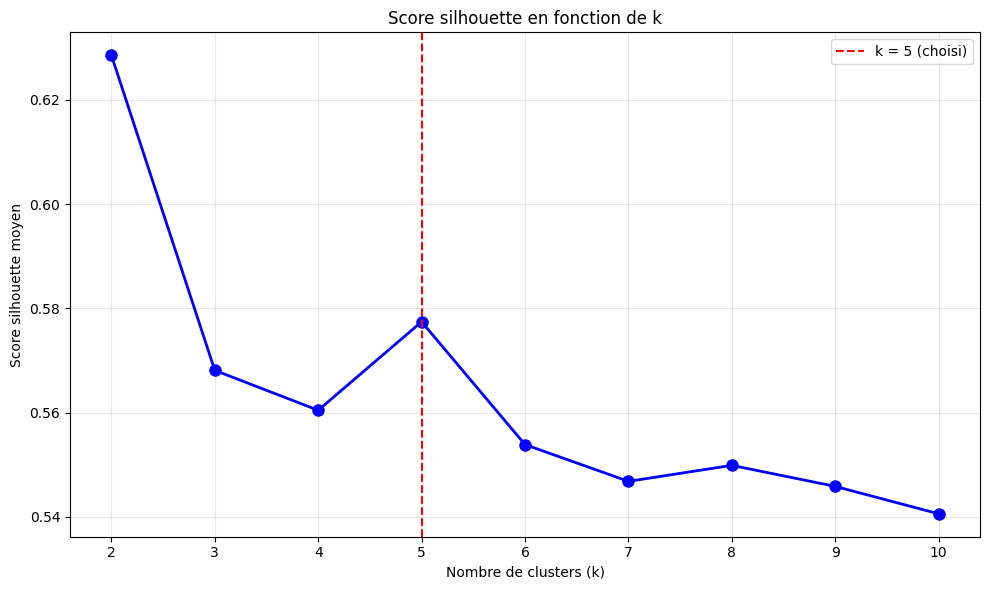

In [4]:
plt.figure(figsize=(10, 6))
plt.plot(list(k_range), scores, 'bo-', linewidth=2, markersize=8)
plt.axvline(x=5, color='r', linestyle='--', label='k = 5 (choisi)')
plt.xlabel('Nombre de clusters (k)')
plt.ylabel('Score silhouette moyen')
plt.title('Score silhouette en fonction de k')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 2. Silhouette plot détaillé pour k=5

In [5]:
k = 5
kmeans = KMeans(n_clusters=k, n_init=10, random_state=42)
labels = kmeans.fit_predict(X)

silhouette_avg = silhouette_score(X, labels)
sample_silhouette_values = silhouette_samples(X, labels)

print(f"Score silhouette moyen (k={k}) : {silhouette_avg:.4f}")

Score silhouette moyen (k=5) : 0.5774


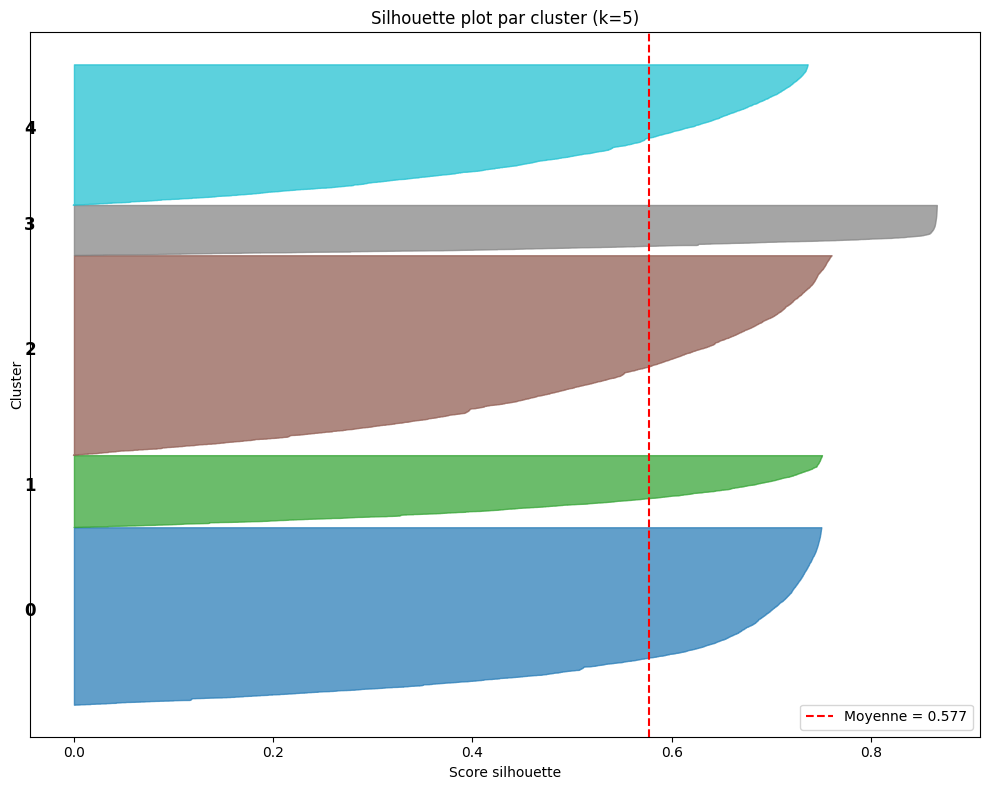

In [6]:
fig, ax = plt.subplots(figsize=(10, 8))

y_lower = 10
colors = cm.tab10(np.linspace(0, 1, k))

for i in range(k):
    cluster_values = sample_silhouette_values[labels == i]
    cluster_values.sort()
    
    size = cluster_values.shape[0]
    y_upper = y_lower + size
    
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values,
                     facecolor=colors[i], edgecolor=colors[i], alpha=0.7)
    ax.text(-0.05, y_lower + 0.5 * size, str(i), fontsize=12, fontweight='bold')
    y_lower = y_upper + 10

ax.axvline(x=silhouette_avg, color='red', linestyle='--',
           label=f'Moyenne = {silhouette_avg:.3f}')
ax.set_xlabel('Score silhouette')
ax.set_ylabel('Cluster')
ax.set_title('Silhouette plot par cluster (k=5)')
ax.set_yticks([])
ax.legend(loc='best')
plt.tight_layout()
plt.show()

## 3. Statistiques par cluster

In [7]:
housing['cluster'] = labels
housing['silhouette'] = sample_silhouette_values

cluster_sil = housing.groupby('cluster').agg(
    effectif=('cluster', 'size'),
    silhouette_moyenne=('silhouette', 'mean'),
    silhouette_min=('silhouette', 'min'),
    pct_negatif=('silhouette', lambda x: (x < 0).mean() * 100)
).round(4)

cluster_sil.columns = ['Effectif', 'Silhouette moy.', 'Silhouette min.', '% négatif']
cluster_sil

,Effectif,Silhouette moy.,Silhouette min.,% négatif
cluster,,,,
0,5731,0.6124,0.0005,0.0000
1,2318,0.5580,-0.0004,0.0431
2,6446,0.5469,-0.0010,0.1551
3,1613,0.7385,0.0059,0.0000
4,4532,0.5293,-0.0012,0.0662


## 4. Interprétation

- Un score silhouette moyen **> 0.5** indique une bonne structure de clustering
- Un score **entre 0.25 et 0.5** indique une structure faible mais existante
- Un score **< 0.25** suggère que les clusters se chevauchent
- Les points avec un score **négatif** sont probablement mal assignés

Les clusters avec un pourcentage élevé de scores négatifs ou une silhouette moyenne basse sont les plus fragiles et pourraient bénéficier d'un découpage différent.